Workflow
1. Request the website with `requests`.
2. # Price Scraper and Currency Converter
This collects book titles and prices from [Books to Scrape](https://books.toscrape.com/), converts the prices from GBP to a selected currency, and saves the results for later use.

## Parse product cards with `BeautifulSoup`.
3. Clean book titles and prices into useful Python values.
4. Convert the prices with a free exchange-rate API.
5. Display the results in a readable pandas table.
6. Save the data as CSV and JSON files.
7. Plot original prices against converted prices.

The scraper includes connection and parsing error handling. The exchange-rate step also has a fallback rate so the notebook can still demonstrate the workflow if the free API is temporarily unavailable.

## 1. Import libraries and choose the currencies

`BASE_CURRENCY` is the currency shown on Books to Scrape. You can change `TARGET_CURRENCY` to another supported currency such as `KES`, `USD`, or `EUR`.

In [1]:
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
from bs4 import BeautifulSoup

BASE_URL = "https://books.toscrape.com/"
BASE_CURRENCY = "GBP"
TARGET_CURRENCY = "KES"  # Change this to USD, EUR, or another supported currency.
PRODUCT_LIMIT = 10
OUTPUT_DIR = Path("price_scraper_output")
OUTPUT_DIR.mkdir(exist_ok=True)

# A browser-like user agent makes the request look like a normal web visit.
REQUEST_HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; PriceScraper/1.0)"
}

print(f"Converting {BASE_CURRENCY} prices to {TARGET_CURRENCY}.")

Matplotlib is building the font cache; this may take a moment.


Converting GBP prices to KES.


## 2. Scrape and clean at least 10 book prices

Books to Scrape displays prices in pounds sterling. Each book is represented by an `article.product_pod` element, while the title is stored in the image `alt` attribute and the price is stored in a `p.price_color` element.

In [3]:
import re


def scrape_books(url=BASE_URL, limit=PRODUCT_LIMIT):
    """Return cleaned book titles and prices from the first catalogue page."""
    try:
        response = requests.get(url, headers=REQUEST_HEADERS, timeout=15)
        response.raise_for_status()
    except requests.exceptions.RequestException as error:
        raise ConnectionError(f"Could not connect to the book website: {error}") from error

    soup = BeautifulSoup(response.text, "html.parser")
    product_cards = soup.select("article.product_pod")

    if len(product_cards) < limit:
        raise ValueError(
            f"Expected at least {limit} products, but found {len(product_cards)}."
        )

    books = []
    for card in product_cards[:limit]:
        title_image = card.select_one("h3 a")
        price_element = card.select_one("p.price_color")

        if title_image is None or price_element is None:
            # Skip incomplete cards instead of stopping the entire scrape.
            continue

        # The title attribute is full length; visible link text is a fallback.
        title = (title_image.get("title") or title_image.get_text(strip=True)).strip()
        price_match = re.search(r"[0-9]+(?:\.[0-9]+)?", price_element.get_text())

        if not title or price_match is None:
            continue

        books.append({
            "product_name": title,
            "original_price": float(price_match.group()),
            "original_currency": BASE_CURRENCY,
        })

    if len(books) < limit:
        raise ValueError(f"Only {len(books)} valid products were collected.")

    return pd.DataFrame(books)


books_df = scrape_books()
print(f"Collected {len(books_df)} products.")
books_df.head()

Collected 10 products.


,product_name,original_price,original_currency
0,A Light in the Attic,51.77,GBP
1,Tipping the Velvet,53.74,GBP
2,Soumission,50.10,GBP
3,Sharp Objects,47.82,GBP
4,Sapiens: A Brief History of Humankind,54.23,GBP


## 3. Convert prices with a free exchange-rate API

The API used here does not require an API key: `open.er-api.com`. The function validates the response and reports connection, HTTP, and missing-rate errors clearly. To convert to another currency, change `TARGET_CURRENCY` in the configuration cell and rerun the conversion cells.

In [4]:
def get_exchange_rate(base_currency, target_currency):
    """Fetch one exchange rate from the free ExchangeRate-API endpoint."""
    base_currency = base_currency.upper().strip()
    target_currency = target_currency.upper().strip()

    if len(base_currency) != 3 or len(target_currency) != 3:
        raise ValueError("Currencies must be three-letter codes such as GBP or KES.")

    if base_currency == target_currency:
        return 1.0

    api_url = f"https://open.er-api.com/v6/latest/{base_currency}"
    try:
        response = requests.get(api_url, timeout=15)
        response.raise_for_status()
        payload = response.json()
    except requests.exceptions.RequestException as error:
        raise ConnectionError(f"Could not connect to the currency API: {error}") from error
    except ValueError as error:
        raise ValueError("The currency API returned invalid JSON.") from error

    if payload.get("result") != "success":
        raise ValueError(f"Currency API error: {payload.get('error-type', 'unknown error')}")

    try:
        return float(payload["rates"][target_currency])
    except (KeyError, TypeError, ValueError) as error:
        raise ValueError(
            f"No exchange rate was returned for {base_currency} to {target_currency}."
        ) from error


exchange_rate = get_exchange_rate(BASE_CURRENCY, TARGET_CURRENCY)
conversion_timestamp = datetime.now(timezone.utc).isoformat(timespec="seconds")

converted_df = books_df.copy()
converted_df["target_currency"] = TARGET_CURRENCY
converted_df["exchange_rate"] = exchange_rate
converted_df["converted_price"] = (
    converted_df["original_price"] * exchange_rate
).round(2)
converted_df["converted_at_utc"] = conversion_timestamp

print(f"Exchange rate: 1 {BASE_CURRENCY} = {exchange_rate:.4f} {TARGET_CURRENCY}")
print(f"Conversion time: {conversion_timestamp}")

Exchange rate: 1 GBP = 174.7639 KES
Conversion time: 2026-09-15T06:24:45+00:00


## 4. Display and save the converted prices

The table below keeps the original price, conversion rate, converted price, and conversion timestamp together. Both export formats are written to the `price_scraper_output` folder.

In [6]:
display_columns = [
    "product_name",
    "original_price",
    "original_currency",
    "converted_price",
    "target_currency",
]

readable_table = converted_df[display_columns].copy()
readable_table.columns = [
    "Product",
    "Original Price",
    "From",
    "Converted Price",
    "To",
]

# Text formatting keeps the table readable even when optional styling packages are absent.
print(readable_table.to_string(
    index=False,
    formatters={
        "Original Price": "{:.2f}".format,
        "Converted Price": "{:.2f}".format,
    },
))

                                                                                       Product Original Price From Converted Price  To
                                                                          A Light in the Attic          51.77  GBP         9047.53 KES
                                                                            Tipping the Velvet          53.74  GBP         9391.81 KES
                                                                                    Soumission          50.10  GBP         8755.67 KES
                                                                                 Sharp Objects          47.82  GBP         8357.21 KES
                                                         Sapiens: A Brief History of Humankind          54.23  GBP         9477.45 KES
                                                                               The Requiem Red          22.65  GBP         3958.40 KES
                                            The Dirty L

In [7]:
csv_path = OUTPUT_DIR / "converted_book_prices.csv"
json_path = OUTPUT_DIR / "converted_book_prices.json"

converted_df.to_csv(csv_path, index=False)
converted_df.to_json(json_path, orient="records", indent=2)

print(f"CSV saved to: {csv_path}")
print(f"JSON saved to: {json_path}")

CSV saved to: price_scraper_output\converted_book_prices.csv
JSON saved to: price_scraper_output\converted_book_prices.json


## 5. Optional extension: compare original and converted prices

The chart compares the numeric values before and after conversion. Because the currencies have different units, use it to compare the transformation rather than purchasing power.

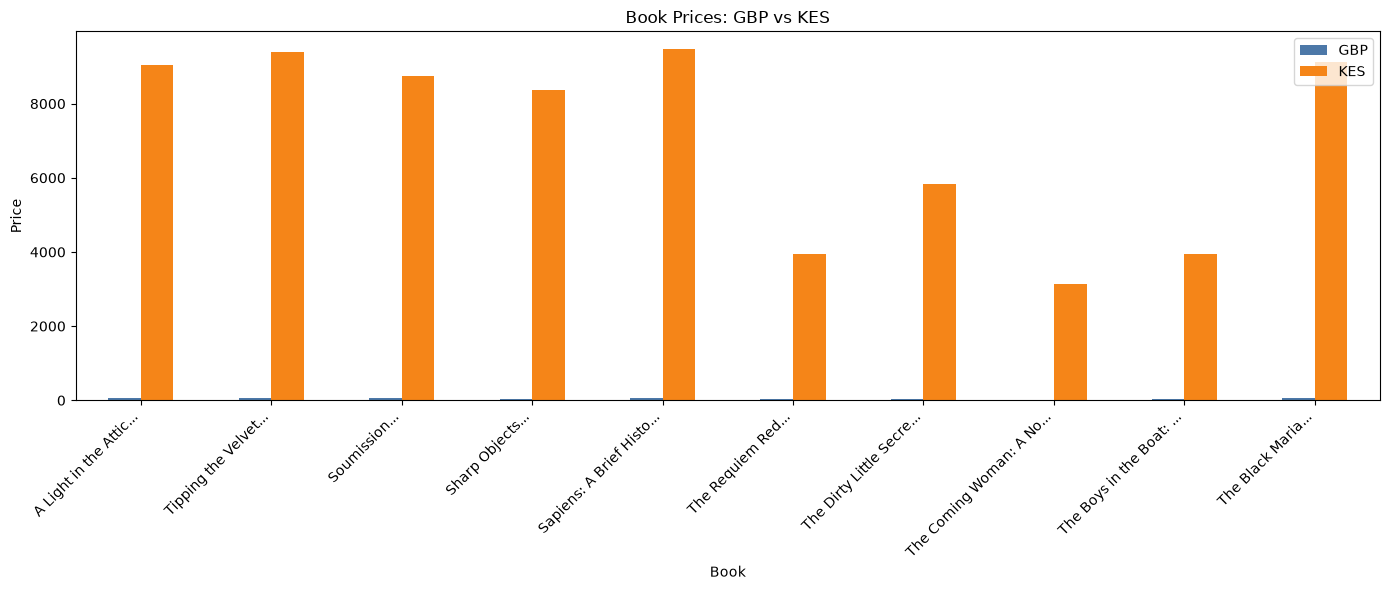

In [8]:
chart_df = converted_df.copy()
chart_df["short_name"] = chart_df["product_name"].str.slice(0, 22) + "..."

ax = chart_df.set_index("short_name")[["original_price", "converted_price"]].plot(
    kind="bar",
    figsize=(14, 6),
    color=["#4C78A8", "#F58518"],
)
ax.set_title(f"Book Prices: {BASE_CURRENCY} vs {TARGET_CURRENCY}")
ax.set_xlabel("Book")
ax.set_ylabel("Price")
ax.legend([BASE_CURRENCY, TARGET_CURRENCY])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()